# TCGA-BRCA Tumor Signature Analysis[¶](#TCGA-BRCA-Tumor-Signature-Analysis)

## Objective[¶](#Objective)

This notebook evaluates whether fibroblast-associated expression is inversely related to cytotoxic lymphocyte activity across primary TCGA breast tumors.

The analysis uses:

* one primary tumor per patient to avoid pseudoreplication,
* variance-stabilized expression values generated with DESeq2,
* a five-gene CAF signature,
* a seven-gene cytotoxic lymphocyte signature,
* both unscaled and gene-wise standardized scoring approaches.

## Metadata[¶](#Metadata)

This notebook uses the annotated tumor metadata table
(`tcga_brca_tumor_metadata_annotated.csv`), which contains one primary
tumor per patient and includes PAM50 molecular subtype labels integrated
from the UCSC Xena TCGA-BRCA clinical matrix.

Maintaining a single annotated metadata table improves reproducibility
and allows downstream analyses to use a consistent set of sample
annotations.

### Biological hypothesis[¶](#Biological-hypothesis)

Tumors with stronger cancer-associated fibroblast activity may exhibit lower cytotoxic lymphocyte activity because fibroblast-rich tumor microenvironments can contribute to immune exclusion or suppression.

The primary statistical expectation is therefore a **negative correlation** between CAF and cytotoxic signature scores.

In [1]:
import pandas as pd

vst = pd.read_csv(
    "data/processed/tcga_brca_tumor_vst_expression.csv",
    index_col=0
)

metadata_tumor = pd.read_csv(
    "data/metadata/tcga_brca_tumor_metadata_annotated.csv"
)


## 1. Load and inspect the tumor cohort[¶](#1.-Load-and-inspect-the-tumor-cohort)

The VST matrix contains genes as rows and tumor samples as columns. The accompanying metadata contains one selected primary tumor per patient.

The first checks confirm matrix dimensions, identifier formats, and agreement between metadata sample barcodes and expression-matrix columns.

In [2]:
print(vst.shape)
print(metadata_tumor.shape)

print(vst.index[:5])
print(vst.columns[:5])

print(metadata_tumor["sample_barcode"].head())


(34142, 1095)
(1095, 11)
Index(['ENSG00000000003.15', 'ENSG00000000005.6', 'ENSG00000000419.13',
       'ENSG00000000457.14', 'ENSG00000000460.17'],
      dtype='object')
Index(['TCGA-3C-AAAU-01A', 'TCGA-3C-AALI-01A', 'TCGA-3C-AALJ-01A',
       'TCGA-3C-AALK-01A', 'TCGA-4H-AAAK-01A'],
      dtype='object')
0    TCGA-3C-AAAU-01A
1    TCGA-3C-AALI-01A
2    TCGA-3C-AALJ-01A
3    TCGA-3C-AALK-01A
4    TCGA-4H-AAAK-01A
Name: sample_barcode, dtype: object


In [3]:
all(metadata_tumor["sample_barcode"].isin(vst.columns))


True

## 2. Add gene annotation[¶](#2.-Add-gene-annotation)

The VST matrix is indexed by versioned Ensembl gene IDs. Gene symbols and gene types are merged from the STAR-derived annotation table.

The merge uses `validate="one_to_one"` so that unexpected duplicate Ensembl identifiers cause an explicit error instead of silently expanding the table.

In [4]:
gene_annotation = pd.read_csv(
    "data/processed/tcga_brca_gene_annotation_from_star_counts.csv"
)

print(gene_annotation.shape)
print(gene_annotation.columns.tolist())
print(gene_annotation.head())


(60660, 3)
['gene_id', 'gene_name', 'gene_type']
              gene_id gene_name       gene_type
0  ENSG00000000003.15    TSPAN6  protein_coding
1   ENSG00000000005.6      TNMD  protein_coding
2  ENSG00000000419.13      DPM1  protein_coding
3  ENSG00000000457.14     SCYL3  protein_coding
4  ENSG00000000460.17  C1orf112  protein_coding


In [5]:
vst_with_annotation = (
    vst
    .reset_index(names="gene_id")
    .merge(
        gene_annotation,
        on="gene_id",
        how="left",
        validate="one_to_one"
    )
)


In [6]:
print(vst_with_annotation.shape)
print(vst_with_annotation[["gene_id", "gene_name", "gene_type"]].head())

print(vst_with_annotation["gene_name"].isna().sum())


(34142, 1098)
              gene_id gene_name       gene_type
0  ENSG00000000003.15    TSPAN6  protein_coding
1   ENSG00000000005.6      TNMD  protein_coding
2  ENSG00000000419.13      DPM1  protein_coding
3  ENSG00000000457.14     SCYL3  protein_coding
4  ENSG00000000460.17  C1orf112  protein_coding
0


## 3. Define biological signatures[¶](#3.-Define-biological-signatures)

Two compact candidate signatures are used:

**CAF signature**

* `FAP`
* `COL1A1`
* `COL1A2`
* `ACTA2`
* `PDGFRB`

These genes capture fibroblast activation, extracellular-matrix production, and stromal contractile features.

**Cytotoxic lymphocyte signature**

* `CD3D`
* `CD3E`
* `CD8A`
* `CD8B`
* `GZMB`
* `PRF1`
* `IFNG`

These genes capture T-cell presence, CD8-lineage identity, and cytotoxic effector activity.

These are transparent, biologically interpretable candidate signatures rather than a claim of a formally validated clinical scoring system.

In [7]:
caf_genes = [
    "FAP",
    "COL1A1",
    "COL1A2",
    "ACTA2",
    "PDGFRB"
]

cytotoxic_genes = [
    "CD3D",
    "CD3E",
    "CD8A",
    "CD8B",
    "GZMB",
    "PRF1",
    "IFNG"
]


## 4. Reorient the expression matrix[¶](#4.-Reorient-the-expression-matrix)

For sample-level scoring, the expression matrix is transposed so that:

* rows represent tumors,
* columns represent genes.

The complete symbol-indexed matrix is inspected for duplicate gene symbols before extracting the signature genes.

In [8]:
expression_by_symbol = (
    vst_with_annotation
    .set_index("gene_name")
    .drop(columns=["gene_id", "gene_type"])
)

expression_by_sample = expression_by_symbol.T


In [9]:
print(expression_by_sample.shape)
print(expression_by_sample.index[:5])
print(expression_by_sample.columns[:10])


(1095, 34142)
Index(['TCGA-3C-AAAU-01A', 'TCGA-3C-AALI-01A', 'TCGA-3C-AALJ-01A',
       'TCGA-3C-AALK-01A', 'TCGA-4H-AAAK-01A'],
      dtype='object')
Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH', 'FUCA2',
       'GCLC', 'NFYA'],
      dtype='object', name='gene_name')


## 5. Extract signature genes and validate uniqueness[¶](#5.-Extract-signature-genes-and-validate-uniqueness)

Only genes used in the two signatures are retained.

Duplicate gene symbols elsewhere in the transcriptome do not affect this analysis. What matters is that each signature gene maps to exactly one expression column. This is verified before scoring.

In [10]:
signature_genes = caf_genes + cytotoxic_genes

signature_expression = (
    vst_with_annotation[
        vst_with_annotation["gene_name"].isin(signature_genes)
    ]
    .set_index("gene_name")
    .drop(columns=["gene_id", "gene_type"])
    .T
)


In [11]:
print(signature_expression.shape)
print(signature_expression.columns.duplicated().sum())
print(signature_expression.columns.tolist())


(1095, 12)
0
['FAP', 'GZMB', 'ACTA2', 'COL1A1', 'IFNG', 'PDGFRB', 'CD8A', 'COL1A2', 'CD3D', 'CD8B', 'PRF1', 'CD3E']


## 6. Calculate mean VST signature scores[¶](#6.-Calculate-mean-VST-signature-scores)

For each tumor, the score is the arithmetic mean of the VST values for the genes in that signature.

This provides a simple and interpretable summary of coordinated expression. Because genes can have different baseline expression levels, a gene-wise standardized sensitivity analysis is performed later.

In [12]:
signature_scores = pd.DataFrame(index=signature_expression.index)

signature_scores["CAF_score"] = (
    signature_expression[caf_genes]
    .mean(axis=1)
)

signature_scores["cytotoxic_score"] = (
    signature_expression[cytotoxic_genes]
    .mean(axis=1)
)


In [13]:
print(signature_scores.shape)
print(signature_scores.head())
print(signature_scores.describe())


(1095, 2)
                  CAF_score  cytotoxic_score
TCGA-3C-AAAU-01A  13.774782         5.412728
TCGA-3C-AALI-01A  14.812179         8.983400
TCGA-3C-AALJ-01A  14.998613         8.584066
TCGA-3C-AALK-01A  15.894139         7.309279
TCGA-4H-AAAK-01A  15.985903         6.755456
         CAF_score  cytotoxic_score
count  1095.000000      1095.000000
mean     14.429586         7.465145
std       1.172478         1.417984
min       8.937400         3.756735
25%      13.745182         6.450667
50%      14.590270         7.350665
75%      15.282737         8.385102
max      17.649938        11.767145


In [14]:
print(
    signature_scores.index.equals(
        pd.Index(metadata_tumor["sample_barcode"])
    )
)


True


## 7. Test the CAF–cytotoxic relationship[¶](#7.-Test-the-CAF%E2%80%93cytotoxic-relationship)

A scatter plot provides a visual assessment of the relationship.

Two correlation measures are calculated:

* **Pearson correlation**, which evaluates linear association.
* **Spearman correlation**, which evaluates monotonic association and is less dependent on linearity.

The original hypothesis would be supported by a meaningful negative coefficient.

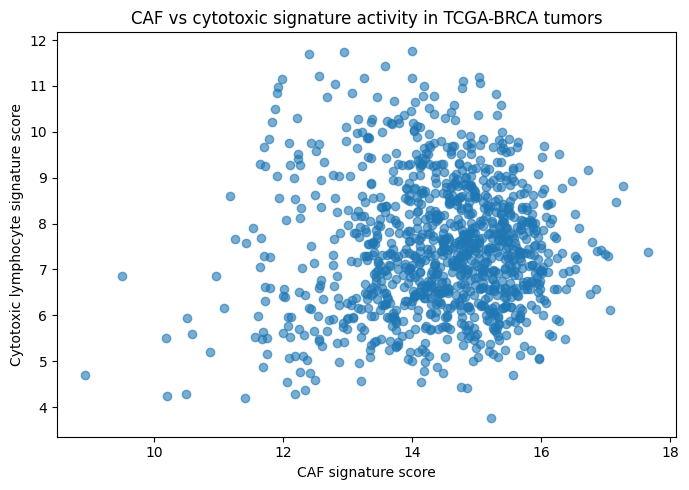

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(
    signature_scores["CAF_score"],
    signature_scores["cytotoxic_score"],
    alpha=0.6
)

plt.xlabel("CAF signature score")
plt.ylabel("Cytotoxic lymphocyte signature score")
plt.title("CAF vs cytotoxic signature activity in TCGA-BRCA tumors")

plt.tight_layout()
plt.show()


In [16]:
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(
    signature_scores["CAF_score"],
    signature_scores["cytotoxic_score"]
)

spearman_r, spearman_p = spearmanr(
    signature_scores["CAF_score"],
    signature_scores["cytotoxic_score"]
)

print("Pearson r:", pearson_r)
print("Pearson p-value:", pearson_p)

print("Spearman rho:", spearman_r)
print("Spearman p-value:", spearman_p)


Pearson r: 0.04433246523335157
Pearson p-value: 0.14263703488132212
Spearman rho: 0.03957922306489644
Spearman p-value: 0.19062770592984052


## 8. Sensitivity analysis: gene-wise z-scoring[¶](#8.-Sensitivity-analysis:-gene-wise-z-scoring)

Before averaging, each signature gene is standardized across tumors:

[
z = \frac{x - \bar{x}}{s}
]

This gives each gene equal scale in the score and reduces the possibility that genes with higher absolute VST values dominate the result.

In [17]:
signature_z = (
    signature_expression
    - signature_expression.mean(axis=0)
) / signature_expression.std(axis=0)

signature_scores_z = pd.DataFrame(index=signature_z.index)

signature_scores_z["CAF_score_z"] = (
    signature_z[caf_genes].mean(axis=1)
)

signature_scores_z["cytotoxic_score_z"] = (
    signature_z[cytotoxic_genes].mean(axis=1)
)


In [18]:
pearson_r, pearson_p = pearsonr(
    signature_scores_z["CAF_score_z"],
    signature_scores_z["cytotoxic_score_z"]
)

spearman_r, spearman_p = spearmanr(
    signature_scores_z["CAF_score_z"],
    signature_scores_z["cytotoxic_score_z"]
)


In [19]:
print("Pearson r:", pearson_r)
print("Pearson p-value:", pearson_p)

print("Spearman rho:", spearman_r)
print("Spearman p-value:", spearman_p)


Pearson r: 0.03948390945731019
Pearson p-value: 0.19169870745464904
Spearman rho: 0.039188201837951485
Spearman p-value: 0.19504957634332018


## 9. Save analysis outputs[¶](#9.-Save-analysis-outputs)

Both the unscaled mean-expression scores and the gene-wise standardized scores are saved for downstream subtype analysis, regression, and visualization.

In [20]:
signature_scores.to_csv(
    "data/processed/tcga_brca_tumor_signature_scores_unscaled.csv"
)

signature_scores_z.to_csv(
    "data/processed/tcga_brca_tumor_signature_scores_zscaled.csv"
)


## 10. Results and interpretation[¶](#10.-Results-and-interpretation)

Across 1,095 TCGA-BRCA primary tumors, the CAF and cytotoxic lymphocyte scores showed essentially no relationship.

### Unscaled mean-expression scores[¶](#Unscaled-mean-expression-scores)

* Pearson (r = 0.0443), (p = 0.1426)
* Spearman (

ho = 0.0396), (p = 0.1906)

### Gene-wise standardized scores[¶](#Gene-wise-standardized-scores)

* Pearson (r = 0.0395), (p = 0.1917)
* Spearman (

ho = 0.0392), (p = 0.1950)

### Interpretation[¶](#Interpretation)

The effect sizes are close to zero, indicating neither a meaningful linear nor monotonic association across the pooled TCGA-BRCA cohort. Therefore, this analysis does **not support the original hypothesis** that tumors with higher CAF activity generally have lower cytotoxic lymphocyte activity.

The conclusion is robust to two reasonable scoring approaches:

1. averaging the original VST values,
2. z-scoring each gene before averaging.

### Important limitations[¶](#Important-limitations)

* Breast cancer molecular subtypes were pooled together, so subtype-specific relationships may be obscured.
* The signatures are compact candidate marker sets rather than externally validated scoring models.
* Bulk RNA-seq cannot distinguish whether expression changes arise from cell abundance, cell state, or both.
* Correlation does not establish a causal relationship between stromal and immune activity.

### Suggested next analyses[¶](#Suggested-next-analyses)

The next priority is to evaluate the relationship within breast cancer subtypes and, where metadata permit, adjust for potential covariates such as tumor purity. A later single-cell or spatial analysis could directly test whether fibroblast-rich regions are locally depleted of cytotoxic lymphocytes.

## 11. PAM50 subtype analysis

The cohort-wide correlation was close to zero, but breast cancer is molecularly heterogeneous. To test whether subtype composition obscures distinct biological patterns, the standardized CAF and cytotoxic scores are merged with the PAM50 RNA-seq classifications.

This section asks two related questions:

1. Do average CAF and cytotoxic signature levels differ across PAM50 subtypes?
2. Does the relationship between the two signatures differ within individual subtypes?

Only tumors with an available PAM50 classification are included in subtype-specific summaries. The Normal-like category is retained because these samples are primary tumor aliquots classified as Normal-like by PAM50 rather than adjacent normal tissue.

In [21]:
signature_scores_z.head()


,CAF_score_z,cytotoxic_score_z
TCGA-3C-AAAU-01A,-0.482998,-1.323554
TCGA-3C-AALI-01A,0.287520,1.005618
TCGA-3C-AALJ-01A,0.448601,0.709254
TCGA-3C-AALK-01A,1.125468,-0.132783
TCGA-4H-AAAK-01A,1.179012,-0.494451


In [22]:
sig_score_z_subtype = (
    signature_scores_z
    .reset_index(names="sample_barcode")
    .merge(
    metadata_tumor[['sample_barcode', 'PAM50Call_RNAseq']],
    on="sample_barcode",
    how="left",
    validate="one_to_one"
    )
)


In [23]:
sig_score_z_subtype.head()


,sample_barcode,CAF_score_z,cytotoxic_score_z,PAM50Call_RNAseq
0,TCGA-3C-AAAU-01A,-0.482998,-1.323554,NaN
1,TCGA-3C-AALI-01A,0.287520,1.005618,NaN
2,TCGA-3C-AALJ-01A,0.448601,0.709254,NaN
3,TCGA-3C-AALK-01A,1.125468,-0.132783,NaN
4,TCGA-4H-AAAK-01A,1.179012,-0.494451,NaN


In [24]:
sig_score_z_subtype[
    "PAM50Call_RNAseq"
].value_counts(dropna=False)


PAM50Call_RNAseq
LumA      421
NaN       253
LumB      192
Basal     139
Her2       67
Normal     23
Name: count, dtype: int64

### 11.1 Descriptive statistics by subtype

For each subtype, the table below reports the number of tumors and the mean and standard deviation of both standardized signatures. These summaries describe the magnitude and direction of subtype differences before formal correlation analysis.

In [25]:
subtype_summary = (
    sig_score_z_subtype
    .dropna(subset=["PAM50Call_RNAseq"])
    .groupby("PAM50Call_RNAseq")
    .agg(
        n=("sample_barcode", "size"),
        CAF_mean=("CAF_score_z", "mean"),
        CAF_sd=("CAF_score_z", "std"),
        cytotoxic_mean=("cytotoxic_score_z", "mean"),
        cytotoxic_sd=("cytotoxic_score_z", "std")
    )
    .reset_index()
)

subtype_summary.round(3)

,PAM50Call_RNAseq,n,CAF_mean,CAF_sd,cytotoxic_mean,cytotoxic_sd
0,Basal,139,-0.517,0.866,0.441,1.010
1,Her2,67,0.186,0.712,0.280,0.922
2,LumA,421,0.272,0.800,-0.214,0.808
3,LumB,192,-0.164,0.874,-0.195,0.920
4,Normal,23,0.369,0.920,0.479,0.904


In [26]:
subtype_order = ["LumA", "LumB", "Her2", "Basal", "Normal"]

subtype_summary["PAM50Call_RNAseq"] = pd.Categorical(
    subtype_summary["PAM50Call_RNAseq"],
    categories=subtype_order,
    ordered=True
)

subtype_summary = (
    subtype_summary
    .sort_values("PAM50Call_RNAseq")
    .reset_index(drop=True)
)

subtype_summary.round(3)


,PAM50Call_RNAseq,n,CAF_mean,CAF_sd,cytotoxic_mean,cytotoxic_sd
0,LumA,421,0.272,0.800,-0.214,0.808
1,LumB,192,-0.164,0.874,-0.195,0.920
2,Her2,67,0.186,0.712,0.280,0.922
3,Basal,139,-0.517,0.866,0.441,1.010
4,Normal,23,0.369,0.920,0.479,0.904


### 11.2 Within-subtype correlations

Pearson and Spearman correlations are calculated separately within each PAM50 subtype. Pearson measures linear association, while Spearman assesses monotonic association and is less sensitive to extreme values. Because five subtype-specific tests are performed for each correlation method, Benjamini–Hochberg false-discovery-rate adjustment is applied.

In [27]:
correlation_results = []

for subtype, group in sig_score_z_subtype.groupby("PAM50Call_RNAseq"):

    # calculate correlations
    pearson_r, pearson_p = pearsonr(
    group["CAF_score_z"],
    group["cytotoxic_score_z"]
    )
    spearman_r, spearman_p = spearmanr(
    group["CAF_score_z"],
    group["cytotoxic_score_z"]
    )
    
    # append results
    correlation_results.append({
        "PAM50_subtype": subtype,
        "n": len(group),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_r,
        "spearman_p": spearman_p
    })


In [28]:
subtype_order = ["LumA", "LumB", "Her2", "Basal", "Normal"]

correlation_results = pd.DataFrame(correlation_results)

correlation_results["PAM50_subtype"] = pd.Categorical(
    correlation_results["PAM50_subtype"],
    categories=subtype_order,
    ordered=True
)

correlation_results = (
    correlation_results
    .sort_values("PAM50_subtype")
    .reset_index(drop=True)
)

correlation_results.round(3)


,PAM50_subtype,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,LumA,421,0.148,0.002,0.130,0.007
1,LumB,192,0.083,0.255,0.095,0.192
2,Her2,67,-0.214,0.082,-0.221,0.073
3,Basal,139,-0.113,0.185,-0.120,0.159
4,Normal,23,0.124,0.572,0.151,0.491


In [29]:
from statsmodels.stats.multitest import multipletests

correlation_results["pearson_p_adj"] = multipletests(
    correlation_results["pearson_p"],
    method="fdr_bh"
)[1]

correlation_results["spearman_p_adj"] = multipletests(
    correlation_results["spearman_p"],
    method="fdr_bh"
)[1]

correlation_results.round(3)


,PAM50_subtype,n,pearson_r,pearson_p,spearman_rho,spearman_p,pearson_p_adj,spearman_p_adj
0,LumA,421,0.148,0.002,0.130,0.007,0.012,0.037
1,LumB,192,0.083,0.255,0.095,0.192,0.319,0.240
2,Her2,67,-0.214,0.082,-0.221,0.073,0.204,0.182
3,Basal,139,-0.113,0.185,-0.120,0.159,0.309,0.240
4,Normal,23,0.124,0.572,0.151,0.491,0.572,0.491


### 11.3 Integrated visualization

The upper panel shows the sample-level relationship between standardized CAF and cytotoxic scores, colored by PAM50 subtype. The lower panels summarize each score's distribution by subtype. Consistent colors are used throughout so that subtype patterns can be compared across panels.

Regression lines are intentionally omitted because the subtype-specific effects are weak and overlapping lines obscure the underlying sample distribution. Exact correlation estimates are reported in the preceding table.

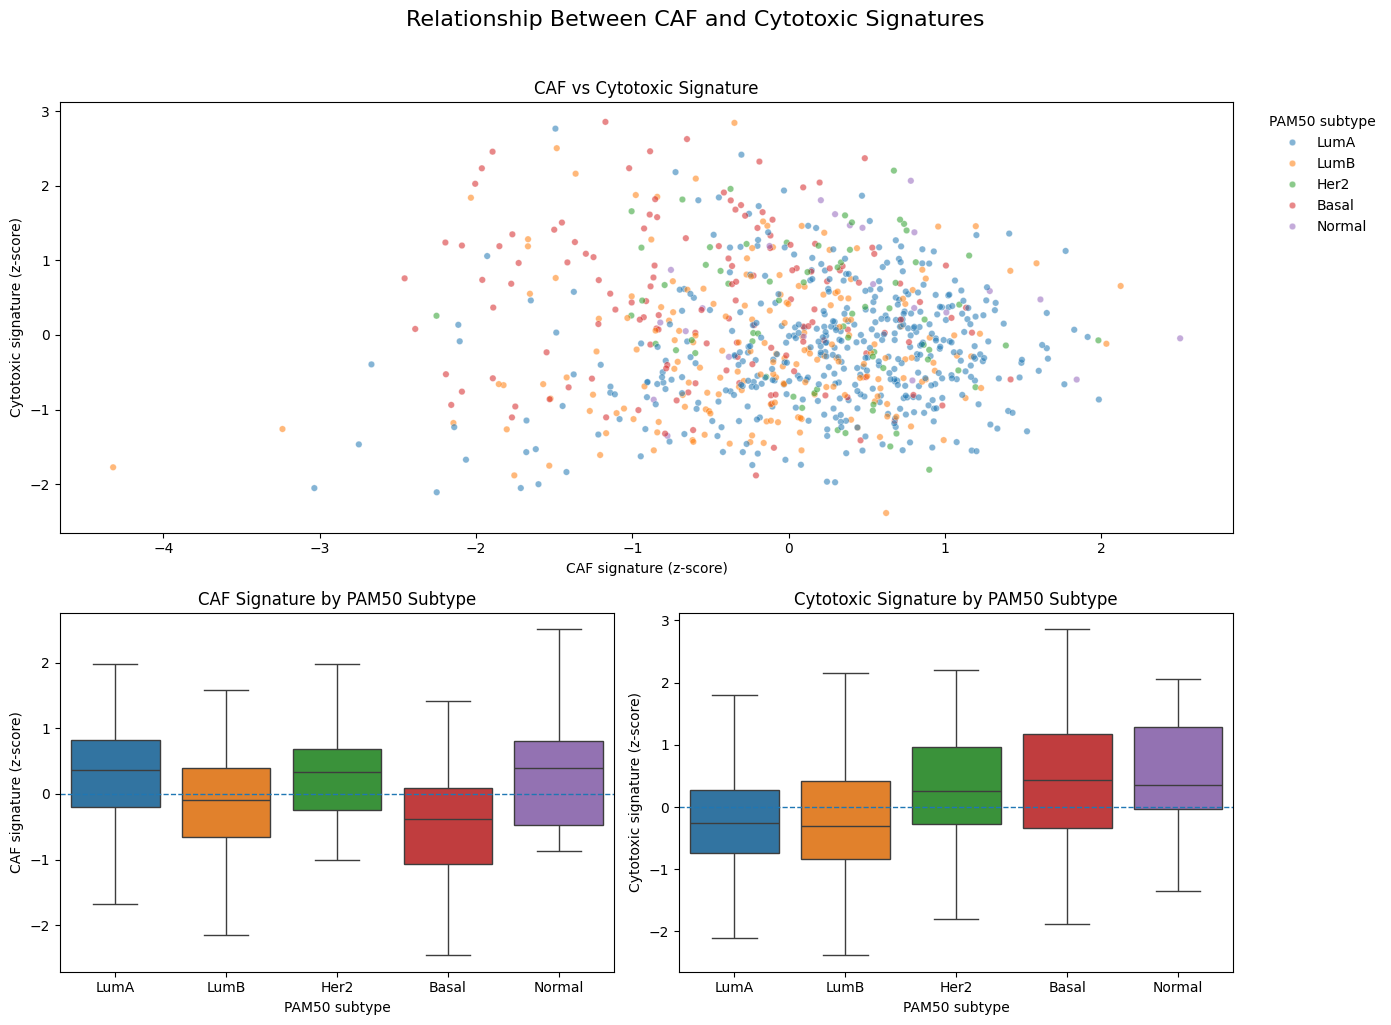

In [30]:
import seaborn as sns
from pathlib import Path

Path("results/figures").mkdir(parents=True, exist_ok=True)
fig = plt.figure(figsize=(14, 10))

grid = fig.add_gridspec(
    2,
    2,
    height_ratios=[1.2, 1]
)

ax_scatter = fig.add_subplot(grid[0, :])
ax_caf = fig.add_subplot(grid[1, 0])
ax_cytotoxic = fig.add_subplot(grid[1, 1])

palette = {
    "LumA": "#1f77b4",
    "LumB": "#ff7f0e",
    "Her2": "#2ca02c",
    "Basal": "#d62728",
    "Normal": "#9467bd",
}

sns.scatterplot(
    data=sig_score_z_subtype,
    x="CAF_score_z",
    y="cytotoxic_score_z",
    hue="PAM50Call_RNAseq",
    hue_order=subtype_order,
    alpha=0.55,
    s=22,
    ax=ax_scatter
)

ax_scatter.set_xlabel("CAF signature (z-score)")
ax_scatter.set_ylabel("Cytotoxic signature (z-score)")
ax_scatter.set_title("CAF vs Cytotoxic Signature")

ax_scatter.legend(
    title="PAM50 subtype",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False)

sns.boxplot(
    data=sig_score_z_subtype,
    x="PAM50Call_RNAseq",
    y="CAF_score_z",
    hue="PAM50Call_RNAseq",
    order=subtype_order,
    hue_order=subtype_order,
    palette=palette,
    legend=False,
    showfliers=False,
    ax=ax_caf
)

ax_caf.set_xlabel("PAM50 subtype")
ax_caf.set_ylabel("CAF signature (z-score)")
ax_caf.set_title("CAF Signature by PAM50 Subtype")


ax_caf.axhline(
    0,
    linestyle="--",
    linewidth=1
)

sns.boxplot(
    data=sig_score_z_subtype,
    x="PAM50Call_RNAseq",
    y="cytotoxic_score_z",
    hue="PAM50Call_RNAseq",
    order=subtype_order,
    hue_order=subtype_order,
    palette=palette,
    legend=False,
    showfliers=False,
    ax=ax_cytotoxic
)


ax_cytotoxic.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax_cytotoxic.set_xlabel("PAM50 subtype")
ax_cytotoxic.set_ylabel("Cytotoxic signature (z-score)")
ax_cytotoxic.set_title("Cytotoxic Signature by PAM50 Subtype")

fig.suptitle(
    "Relationship Between CAF and Cytotoxic Signatures",
    fontsize=16,
    y=1.02
)

fig.tight_layout()

fig.savefig(
    "results/figures/tcga_brca_pam50_signature_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "results/figures/tcga_brca_pam50_signature_analysis.pdf",
    bbox_inches="tight"
)

plt.show()


## 12. Conclusions

### Main findings

Across 1,095 primary TCGA-BRCA tumors, CAF and cytotoxic lymphocyte signature scores were essentially uncorrelated in the full cohort. This result was robust to whether genes were averaged on the original VST scale or standardized gene-by-gene before scoring.

PAM50 stratification revealed clear differences in signature distributions:

- **Basal-like tumors** had the lowest average CAF score and the highest average cytotoxic score.
- **Luminal A tumors** had relatively higher CAF scores and lower cytotoxic scores.
- **HER2-enriched tumors** showed intermediate-to-high values for both signatures.
- **Normal-like tumors** appeared relatively high for both scores, but this group contained only 23 tumors and should be interpreted cautiously.

Within-subtype correlations remained small. Luminal A tumors showed a statistically detectable but weak positive association between CAF and cytotoxic scores (Pearson *r* ≈ 0.15; Spearman ρ ≈ 0.13), while the other subtypes did not show clear evidence of association after accounting for multiple testing.

### Biological interpretation

The original hypothesis predicted that stronger fibroblast-associated expression would accompany reduced cytotoxic lymphocyte activity. These bulk RNA-seq data do **not** support a strong, general inverse relationship across TCGA-BRCA tumors. Instead, the dominant pattern is subtype-level heterogeneity: PAM50 subtype shifts the average levels of both signatures, but substantial variation remains within every subtype.

A likely limitation is that bulk RNA-seq averages expression across malignant, stromal, and immune cells. A tumor may therefore have high fibroblast and high cytotoxic signals simultaneously if both cell populations are abundant. The analysis also uses compact marker sets rather than validated pathway-level signatures, and it does not adjust for tumor purity or other clinical covariates.

### Next steps

This bulk analysis establishes a reproducible baseline and motivates higher-resolution follow-up. Single-cell RNA-seq can determine whether CAF states and cytotoxic lymphocyte states co-occur within the same tumors, while spatial transcriptomics can test whether cytotoxic cells are excluded from CAF-rich regions. Those approaches are better suited to evaluating a spatial or cell-type-specific exclusion mechanism than bulk expression alone.